# Posterior distribution and limit to thawing

### Part (i): visualize

In [28]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
import os
import scipy.io
import xarray as xr
sys.path.append('../')

from src.utilities import low_high_percentile


# bedmap load in
bedmap_path = "/home/donglaiyang/Documents/Georgia-Tech/Research/common-data-set/bed-topography/bedmap3AIS.nc"
bedmap_ds = xr.open_dataset(bedmap_path)
bedmap_x = bedmap_ds['x'].values
bedmap_y = bedmap_ds['y'].values
bedmap_s = bedmap_ds['surface_topography'].values
bedmap_b = bedmap_ds['bed_topography'].values

# posterior data load in
posterior_sample_path = "../data/posterior-hmc-samples/hmc_samples.npz"
posterior_samples = np.load(posterior_sample_path)
print(posterior_samples)

# load mask
data_path = os.getenv('DATA_PATH')
mask_path = data_path + 'training_mask_domain_continuous.mat'
model_bound_data = scipy.io.loadmat(mask_path)
model_bound_data = model_bound_data['in_domain_mask']


NpzFile '../data/posterior-hmc-samples/hmc_samples.npz' with keys: Tb_samples, posterior_mean_Tb, posterior_std_Tb, log_probs, Tpmp...


In [6]:
# low lower and upper bound
low_bound, high_bound = low_high_percentile(posterior_samples["Tb_samples"],
                                            posterior_samples["log_probs"], 
                                            low_percentile=5, high_percentile=95)
# get posterior mean
mean_val = np.mean(posterior_samples["Tb_samples"], axis=0)

# deg to val
deg_to_low_bound  = (posterior_samples["Tpmp"] - low_bound).reshape(256, 256)
deg_to_high_bound = (posterior_samples["Tpmp"] - high_bound).reshape(256, 256)
deg_to_mean_val   = (posterior_samples["Tpmp"] - mean_val).reshape(256, 256)

# use mask to nan areas outside
deg_to_low_bound[model_bound_data == 0] = np.nan
deg_to_high_bound[model_bound_data == 0] = np.nan
deg_to_mean_val[model_bound_data == 0] = np.nan

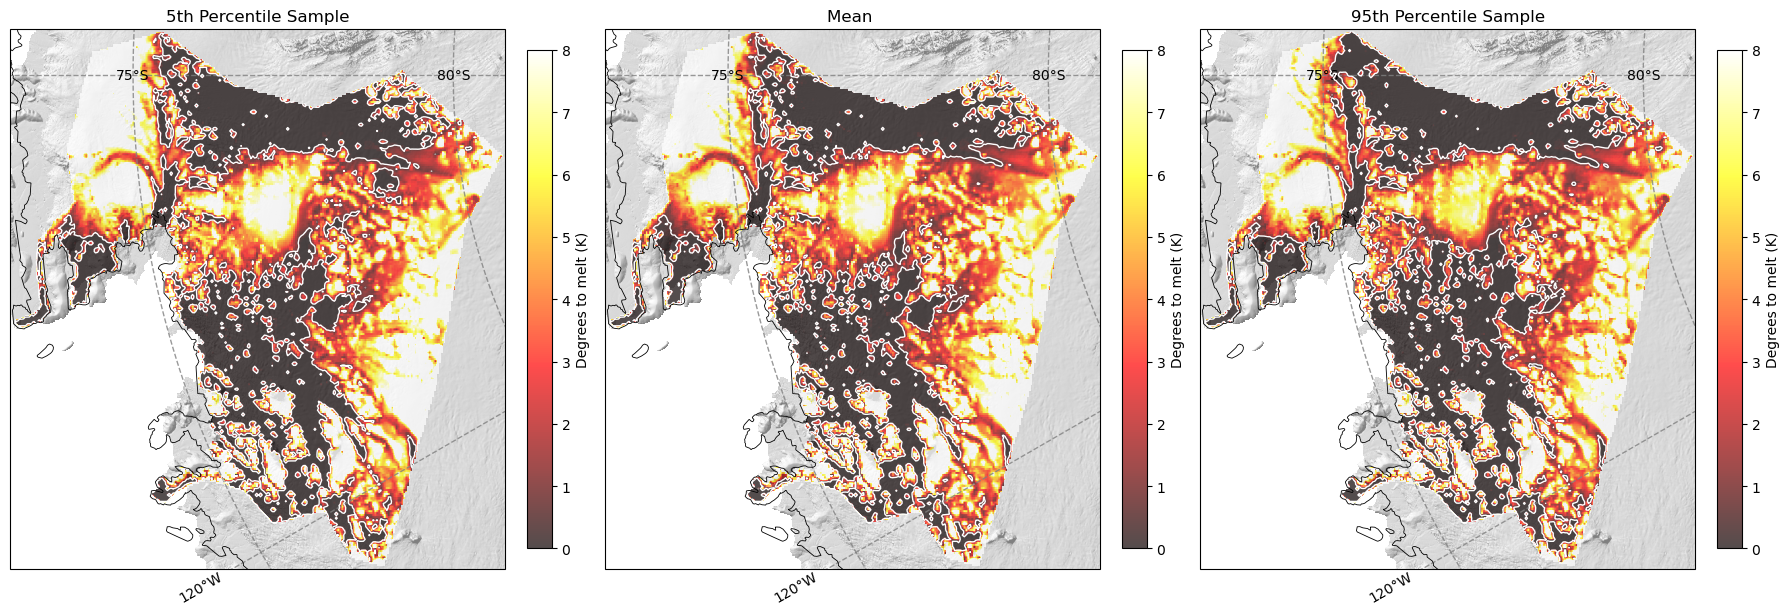

In [29]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

proj     = ccrs.SouthPolarStereo()
data_crs = ccrs.epsg(3031)

fig, axes = plt.subplots(1, 3,
                         figsize=(18, 7),
                         subplot_kw={'projection': proj})

x_min, x_max = np.min(posterior_samples["x_coord"]), np.max(posterior_samples["x_coord"])
y_min, y_max = np.min(posterior_samples["y_coord"]), np.max(posterior_samples["y_coord"])

# preparing hillshade DEM
buffer = 50000  # 50 km buffer in meters
mask_x = (bedmap_x >= x_min - buffer) & (bedmap_x <= x_max + buffer)
mask_y = (bedmap_y >= y_min - buffer) & (bedmap_y <= y_max + buffer)
dem_crop = bedmap_s[np.ix_(mask_y, mask_x)]
bed_crop = bedmap_b[np.ix_(mask_y, mask_x)]
x_crop   = bedmap_x[mask_x]
y_crop   = bedmap_y[mask_y]
# lightsource
ls = LightSource(azdeg=315, altdeg=45) 
hillshade = ls.hillshade(dem_crop,
                         vert_exag=20,
                         dx=np.abs(x_crop[1] - x_crop[0]),
                         dy=np.abs(y_crop[1] - y_crop[0]))

for ax in axes:
    ax.set_extent([x_min, x_max, y_min, y_max], crs=data_crs)
    ax.add_feature(cfeature.COASTLINE, zorder=3, edgecolor='black', linewidth=0.6)
    # Gridlines
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),       
        draw_labels=True,
        linewidth=1,
        color='grey',
        alpha=0.8,
        linestyle='--',
        zorder=5                    
    )
    gl.top_labels    = False          # suppress crowded top labels
    gl.right_labels  = False
    gl.xlabel_style  = {'size': 10, 'color': 'black'}
    gl.ylabel_style  = {'size': 10, 'color': 'black'}
    gl.xlocator = plt.FixedLocator(range(-180, 181, 30))   # every 30° longitude
    gl.ylocator = plt.FixedLocator(range(-90, -59, 5))     # every 5° latitude from -90 to -60
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER


im0 = axes[0].imshow(
    deg_to_low_bound.reshape(256, 256),
    origin='lower',                        
    extent=[x_min, x_max, y_min, y_max], 
    transform=data_crs,
    cmap='hot', vmin=0, vmax=8,
    alpha=0.7,
    zorder=1
)
# axes[0].invert_yaxis()
axes[0].contour(
    np.linspace(x_min, x_max, 256),       # x coords
    np.linspace(y_min, y_max, 256),       # y coords
    deg_to_low_bound.reshape(256, 256),
    levels=[0.5], colors='white', linewidths=1,
    transform=data_crs, zorder=2
)
# add ice surface topography as hillshade 
axes[0].imshow(
    hillshade,
    origin='upper',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='gray',
    alpha=0.5,
    zorder=0
)
axes[0].set_title("5th Percentile Sample")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04,
             label='Degrees to melt (K)')

# --- axes[1]: mean value ---
im1 = axes[1].imshow(
    deg_to_mean_val.reshape(256, 256),
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot', vmin=0, vmax=8,
    alpha=0.7,
    zorder=1
)
axes[1].contour(
    np.linspace(x_min, x_max, 256),
    np.linspace(y_min, y_max, 256),
    deg_to_mean_val.reshape(256, 256),
    levels=[0.5], colors='white', linewidths=1,
    transform=data_crs, zorder=2
)
# add ice surface topography as hillshade 
axes[1].imshow(
    hillshade,
    origin='upper',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='gray',
    alpha=0.5,
    zorder=0
)
axes[1].set_title("Mean ")

fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04,
             label='Degrees to melt (K)')

# --- axes[2]: 95th percentile ---
im2 = axes[2].imshow(
    deg_to_high_bound.reshape(256, 256),
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot', vmin=0, vmax=8,
    alpha=0.7,
    zorder=1
)
axes[2].contour(
    np.linspace(x_min, x_max, 256),
    np.linspace(y_min, y_max, 256),
    deg_to_high_bound.reshape(256, 256),
    levels=[0.5], colors='white', linewidths=1,
    transform=data_crs, zorder=2
)
# add ice surface topography as hillshade 
axes[2].imshow(
    hillshade,
    origin='upper',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='gray',
    alpha=0.5,
    zorder=0
)
axes[2].set_title("95th Percentile Sample")

fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04,
             label='Degrees to melt (K)')

plt.tight_layout()
plt.savefig("../figs/low_mean_high_posterior_samples.png", dpi=300)
plt.show()


### Part (ii): limit to thawing

Valid pixel indices:  [  445   446   447 ... 65101 65102 65103]
Total number of valid pixels in the domain:  34118


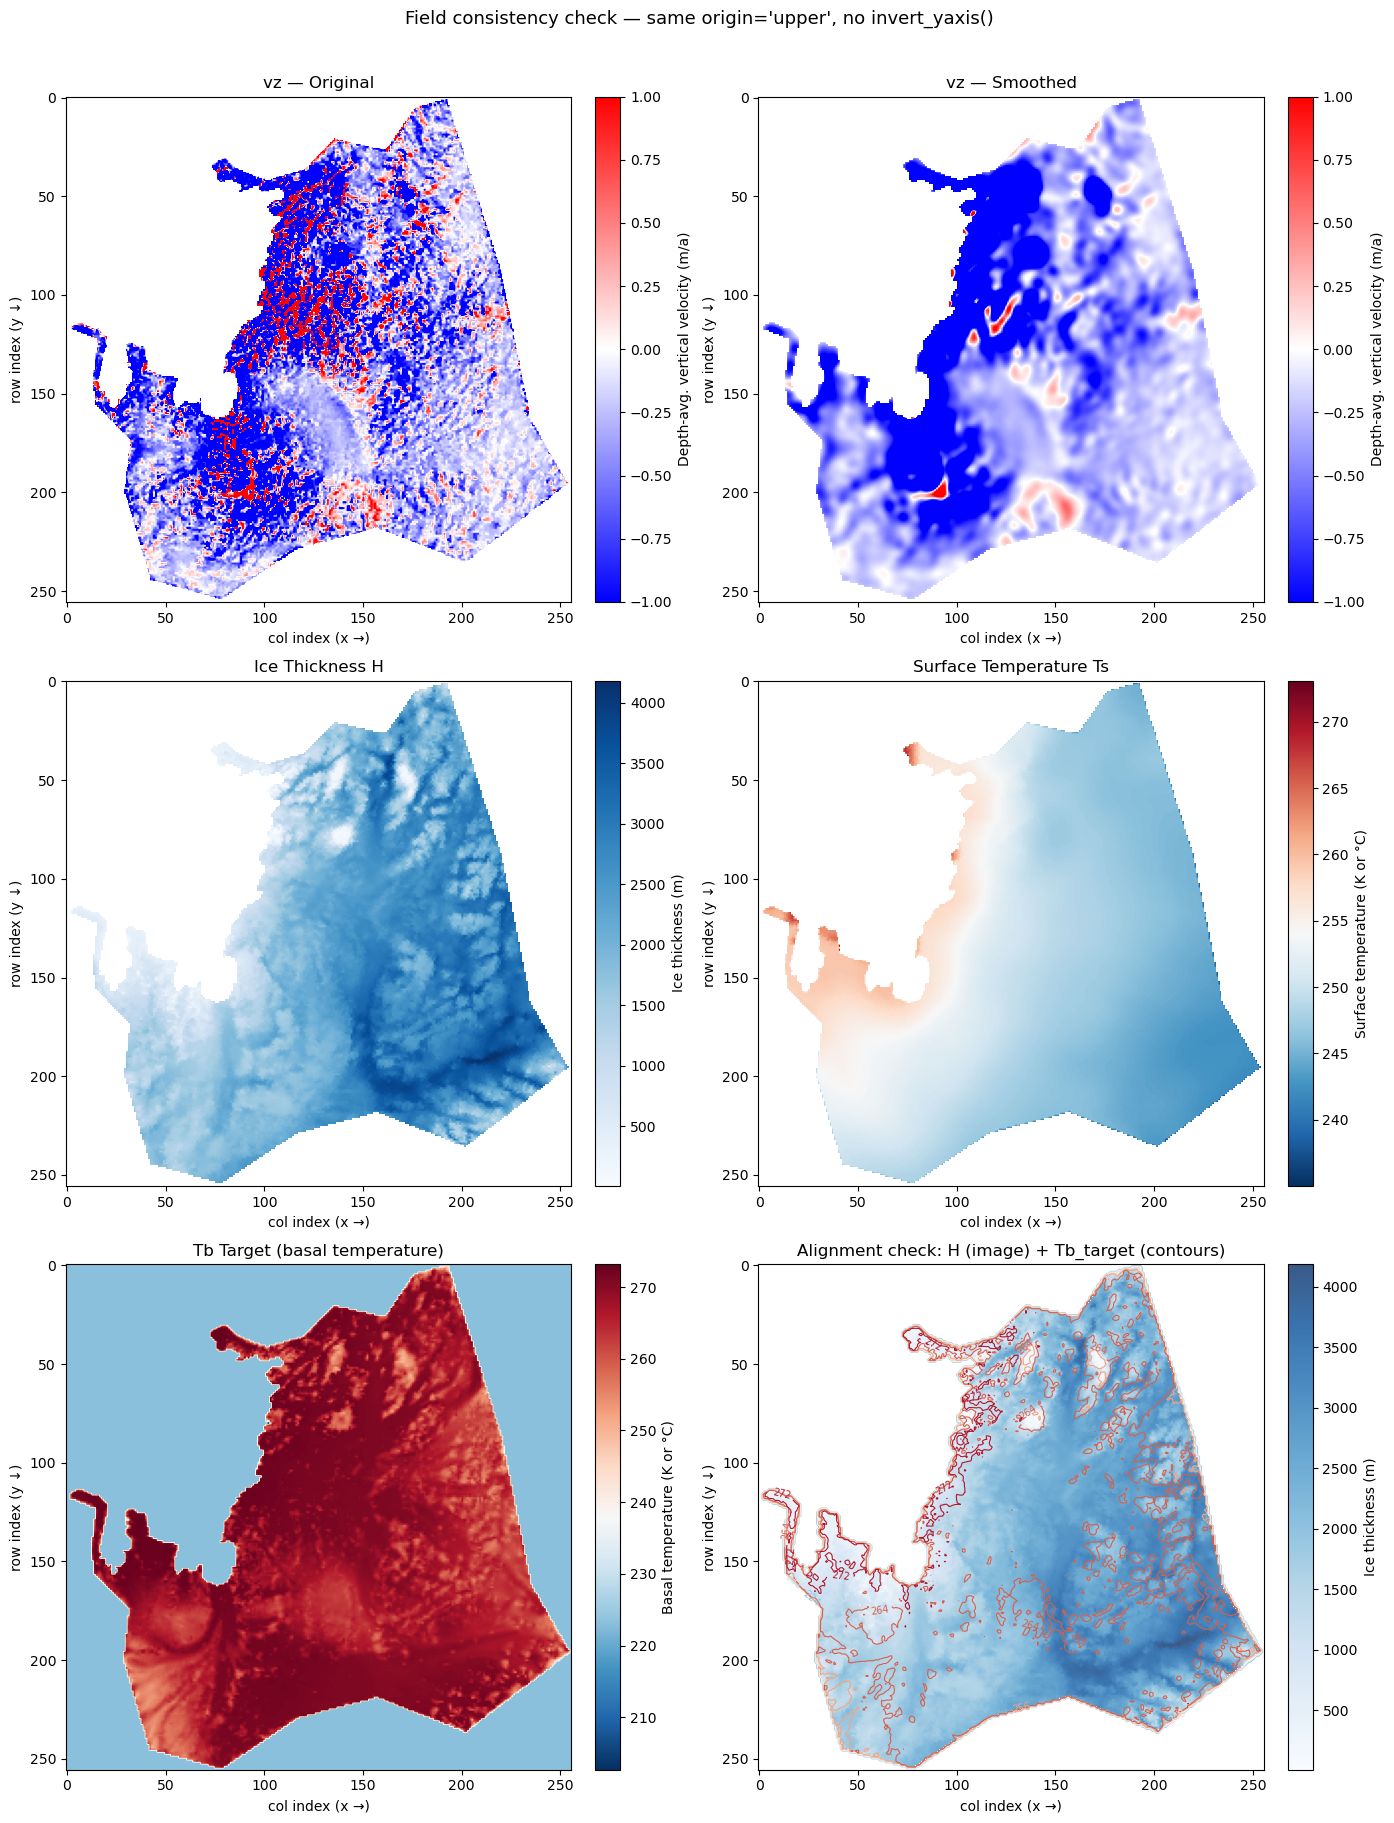

In [8]:
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# add the thermal solver
sys.path.append('../../exfiltration-thermal-feedback/')
from iceThermalNumericalSolve import ice_thermal_numeric

# load surface temperature and depth-averaged vertical velocity from four steady state ISSM model output
vz = scipy.io.loadmat("../data/input-time-dependent-thermal/vz-depth-averaged.mat")['vz']
Ts = scipy.io.loadmat("../data/input-time-dependent-thermal/Ts.mat")['Ts']
H  = scipy.io.loadmat("../data/input-time-dependent-thermal/H.mat")['H']
vz_x = vz['x'][0][0]
vz_y = vz['y'][0][0]
vz_val = vz['mean'][0][0]
Ts_x = Ts['x'][0][0]
Ts_y = Ts['y'][0][0]
Ts_val = Ts['val'][0][0]
H_x = H['x'][0][0]
H_y = H['y'][0][0]
H_val = H['val'][0][0]

# interpolate the scattered val to our grid
grid_x, grid_y = np.meshgrid(posterior_samples["x_coord"], posterior_samples["y_coord"])
vz_grid = griddata((vz_x.flatten(), vz_y.flatten()), vz_val.flatten(), (grid_x, grid_y), method='nearest')
Ts_grid = griddata((Ts_x.flatten(), Ts_y.flatten()), Ts_val.flatten(), (grid_x, grid_y), method='nearest')
H_grid  = griddata((H_x.flatten(), H_y.flatten()), H_val.flatten(), (grid_x, grid_y), method='nearest')
# apply 2D gaussian smoothing to just vz

vz_grid_smooth = gaussian_filter(vz_grid, sigma=2) # sigma is grid cell
Ts_grid[model_bound_data == 0]        = np.nan
vz_grid[model_bound_data == 0]        = np.nan
vz_grid_smooth[model_bound_data == 0] = np.nan
H_grid[model_bound_data == 0]         = np.nan
del vz, Ts, H

valid_pixel = np.isfinite(deg_to_mean_val)
valid_pixel_idx = np.where(valid_pixel.flatten())[0]
print("Valid pixel indices: ", valid_pixel_idx)
print("Total number of valid pixels in the domain: ", np.sum(valid_pixel))

# target bed temperature
Tb_target = mean_val.reshape(256, 256)


fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# ─── Shared plot kwargs for consistency ───────────────────────────────────────
imshow_kw = dict(origin='upper', aspect='equal')

# ─── Row 0: Vertical velocity (before / after smoothing) ─────────────────────
im0 = axes[0, 0].imshow(vz_grid, cmap='bwr', vmin=-1, vmax=1, **imshow_kw)
axes[0, 0].set_title("vz — Original")
axes[0, 0].set_xlabel("col index (x →)")
axes[0, 0].set_ylabel("row index (y ↓)")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04,
             label='Depth-avg. vertical velocity (m/a)')

im1 = axes[0, 1].imshow(vz_grid_smooth, cmap='bwr', vmin=-1, vmax=1, **imshow_kw)
axes[0, 1].set_title("vz — Smoothed")
axes[0, 1].set_xlabel("col index (x →)")
axes[0, 1].set_ylabel("row index (y ↓)")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04,
             label='Depth-avg. vertical velocity (m/a)')

# ─── Row 1: Ice thickness / Surface temperature ───────────────────────────────
im2 = axes[1, 0].imshow(H_grid, cmap='Blues', **imshow_kw)
axes[1, 0].set_title("Ice Thickness H")
axes[1, 0].set_xlabel("col index (x →)")
axes[1, 0].set_ylabel("row index (y ↓)")
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label='Ice thickness (m)')

im3 = axes[1, 1].imshow(Ts_grid, cmap='RdBu_r', **imshow_kw)
axes[1, 1].set_title("Surface Temperature Ts")
axes[1, 1].set_xlabel("col index (x →)")
axes[1, 1].set_ylabel("row index (y ↓)")
fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Surface temperature (K or °C)')

# ─── Row 2: Basal temperature target / empty slot ────────────────────────────
im4 = axes[2, 0].imshow(Tb_target, cmap='RdBu_r', **imshow_kw)
axes[2, 0].set_title("Tb Target (basal temperature)")
axes[2, 0].set_xlabel("col index (x →)")
axes[2, 0].set_ylabel("row index (y ↓)")
fig.colorbar(im4, ax=axes[2, 0], fraction=0.046, pad=0.04, label='Basal temperature (K or °C)')

# ─── Row 2 right: overlay Tb_target contour on H to cross-check alignment ────
im5 = axes[2, 1].imshow(H_grid, cmap='Blues', alpha=0.8, **imshow_kw)
cs  = axes[2, 1].contour(Tb_target, levels=8, cmap='RdBu_r', linewidths=0.8)
axes[2, 1].clabel(cs, inline=True, fontsize=7)
axes[2, 1].set_title("Alignment check: H (image) + Tb_target (contours)")
axes[2, 1].set_xlabel("col index (x →)")
axes[2, 1].set_ylabel("row index (y ↓)")
fig.colorbar(im5, ax=axes[2, 1], fraction=0.046, pad=0.04, label='Ice thickness (m)')

plt.suptitle("Field consistency check — same origin='upper', no invert_yaxis()", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
from contextlib import contextmanager
from joblib import Parallel, delayed
from tqdm import tqdm
import time

@contextmanager
def suppress_output():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        try:
            sys.stdout = devnull
            sys.stderr = devnull
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# --------------------------------------------
secinyear = 365*24*3600
year_final = 100
nz = 100
ghf_span = np.linspace(20, 300, 10) * 1e-3

Tb_target = mean_val.reshape(256, 256)

Tb_misfit        = np.nan * np.ones_like(Tb_target.flatten())
ghf_optimal      = np.nan * np.ones_like(Tb_target.flatten())
convergence_flag = np.zeros_like(Tb_target.flatten(), dtype=bool)
T_profile        = np.nan * np.ones((Tb_target.flatten().size, nz+1))

pixels_to_run = valid_pixel_idx

pbar = tqdm(enumerate(pixels_to_run),
            total=len(pixels_to_run),
            desc="Thermal inversion",
            unit="px")

for count, idx in pbar:
    t0 = time.perf_counter()

    h_val         = H_grid.flatten()[idx]
    Ts_val        = Ts_grid.flatten()[idx]
    vz_val        = vz_grid_smooth.flatten()[idx]
    Tb_target_val = Tb_target.flatten()[idx]

    if h_val < 50:
        pbar.write(f"[SKIP] Pixel {idx}: ice too thin ({h_val:.1f} m)")
        continue

    T_init = Ts_val * np.ones_like(md_it.z)

    for ghf in ghf_span:
        vz_profile = np.linspace(0, 2*vz_val, md_it.z.size) / secinyear
        vz_profile = vz_profile[::-1]

        with suppress_output():
            md_it = ice_thermal_numeric(T_init, year_final, intSave=200, nz=nz, L=h_val)
            md_it.load_advection(md_it.z, vz_profile)
            md_it.apply_surface_bc(Ts_val)
            md_it.apply_base_bc(ghf)
            md_it.solve_steady_state(show_plot=False)

        T_md  = md_it.T_ss[-1]
        Tb_md = T_md[-1]
        misfit = Tb_target_val - Tb_md

        if misfit < 0:
            convergence_flag[idx] = True
            break
        else:
            T_init = T_md

    Tb_misfit[idx]   = misfit
    ghf_optimal[idx] = ghf
    T_profile[idx,:] = T_md

    # --- timing & progress bar update ---
    elapsed = time.perf_counter() - t0
    pbar.set_postfix({
        'idx'    : idx,
        'ghf'    : f'{ghf*1e3:.1f} mW/m²',
        'misfit' : f'{misfit:.2f} K',
        'conv'   : '✓' if convergence_flag[idx] else '✗',
        's/px'   : f'{elapsed:.1f}s'
    })

    if count % 10 == 0:
        pbar.write(
            f"[{count:>4d}/{len(pixels_to_run)}] idx={idx} | "
            f"ghf={ghf*1e3:.1f} mW/m² | misfit={misfit:.3f} K | "
            f"time/px={elapsed:.1f}s"
        )

pbar.close()


Thermal inversion:   0%|          | 1/34118 [00:00<1:58:50,  4.78px/s, idx=445, ghf=82.2 mW/m², misfit=-0.87 K, conv=✓, s/px=0.2s]

[   0/34118] idx=445 | ghf=82.2 mW/m² | misfit=-0.867 K | time/px=0.2s


Thermal inversion:   0%|          | 11/34118 [00:03<2:55:55,  3.23px/s, idx=702, ghf=113.3 mW/m², misfit=-0.15 K, conv=✓, s/px=0.3s]

[  10/34118] idx=702 | ghf=113.3 mW/m² | misfit=-0.152 K | time/px=0.3s


Thermal inversion:   0%|          | 21/34118 [00:08<4:13:34,  2.24px/s, idx=956, ghf=237.8 mW/m², misfit=-0.37 K, conv=✓, s/px=0.5s]

...

[ 150/34118] idx=2733 | ghf=82.2 mW/m² | misfit=-3.113 K | time/px=0.8s


Thermal inversion:   0%|          | 161/34118 [01:48<6:50:26,  1.38px/s, idx=2743, ghf=237.8 mW/m², misfit=-3.52 K, conv=✓, s/px=0.5s]

[ 160/34118] idx=2743 | ghf=237.8 mW/m² | misfit=-3.521 K | time/px=0.5s


Thermal inversion:   0%|          | 168/34118 [01:51<6:16:38,  1.50px/s, idx=2750, ghf=268.9 mW/m², misfit=-0.64 K, conv=✓, s/px=0.5s]


KeyboardInterrupt: 

In [9]:
import os
import sys
import signal
import numpy as np
from contextlib import contextmanager
from tqdm import tqdm
import time
import pickle

# ─── Helpers ──────────────────────────────────────────────────────────────────

@contextmanager
def suppress_output():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        try:
            sys.stdout = devnull
            sys.stderr = devnull
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

class TimeoutException(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutException()

# ─── Per-pixel function ────────────────────────────────────────────────────────

def process_pixel_init(idx, timeout_sec=60):
    """   
    A pixel-wise "initialization" function to find the geothermal heat flux (ghf) that 
    best matches the target basal temperature (Tb_target) for a given pixel index `idx`. 
    The function runs a 1D steady-state thermal model with advection and iteratively adjusts 
    the basal heat flux until the modeled basal temperature (Tb_md) is just below the target (Tb_target_val).
    """
    h_val         = H_grid.flatten()[idx]
    Ts_val        = Ts_grid.flatten()[idx]
    vz_val        = vz_grid_smooth.flatten()[idx]
    Tb_target_val = Tb_target.flatten()[idx]

    if h_val < 50:
        return idx, np.nan, np.nan, np.nan * np.ones(nz + 1), False, 'thin_ice'

    T_init    = Ts_val * np.ones(nz + 1)
    converged = False
    ghf_found = np.nan
    misfit    = np.nan
    T_md      = np.nan * np.ones(nz + 1)

    signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(timeout_sec)

    try:
        for ghf_idx, ghf in enumerate(ghf_span):
            vz_profile = np.linspace(0, 2 * vz_val, nz + 1) / secinyear
            vz_profile = vz_profile[::-1]

            # print BEFORE suppressor so it is always visible
            # print(f"  → idx={idx} | ghf={ghf*1e3:.1f} mW/m² ({ghf_idx+1}/{len(ghf_span)})",
            #       flush=True)

            with suppress_output():
                md_it = ice_thermal_numeric(T_init, year_final, intSave=200, nz=nz, L=h_val)
                md_it.load_advection(md_it.z, vz_profile)
                md_it.apply_surface_bc(Ts_val)
                md_it.apply_base_bc(ghf)
                md_it.solve_steady_state(show_plot=False)

            T_md  = md_it.T_ss[-1]
            Tb_md = T_md[-1]
            misfit = Tb_target_val - Tb_md

            if misfit < 0:
                converged = True
                ghf_found = ghf
                break
            else:
                T_init = T_md

        if not converged:
            ghf_found = ghf_span[-1]

        status = 'converged' if converged else 'no_convergence'

    except TimeoutException:
        status    = 'timeout'
        converged = False
        ghf_found = np.nan
        print(f"  ⚠ TIMEOUT at idx={idx}", flush=True)

    finally:
        signal.alarm(0)   # always cancel alarm regardless of outcome

    return idx, misfit, ghf_found, T_md, converged, status

# ─── Setup ────────────────────────────────────────────────────────────────────

secinyear  = 365 * 24 * 3600
year_final = 100
nz         = 100
ghf_span   = np.linspace(20, 300, 10) * 1e-3

Tb_target = mean_val.reshape(256, 256)

Tb_misfit        = np.nan * np.ones_like(Tb_target.flatten())
ghf_optimal      = np.nan * np.ones_like(Tb_target.flatten())
convergence_flag = np.zeros_like(Tb_target.flatten(), dtype=bool)
timeout_flag     = np.zeros_like(Tb_target.flatten(), dtype=bool)
T_profile        = np.nan * np.ones((Tb_target.flatten().size, nz + 1))

pixels_to_run = valid_pixel_idx  # run all; slice here if testing e.g. valid_pixel_idx[:100]


In [ ]:
import pickle

# ─── Load checkpoint ──────────────────────────────────────────────────────────

with open("checkpoint_34000.pkl", "rb") as f:
    checkpoint = pickle.load(f)

Tb_misfit        = checkpoint["Tb_misfit"]
ghf_optimal      = checkpoint["ghf_optimal"]
T_profile        = checkpoint["T_profile"]
convergence_flag = checkpoint["convergence_flag"]
timeout_flag     = checkpoint["timeout_flag"]
resume_count     = checkpoint["last_count"]   # == 34000

print(f"[RESUME] Resuming after count={resume_count}")

# ─── Main loop ────────────────────────────────────────────────────────────────

pbar = tqdm(enumerate(pixels_to_run[resume_count + 1:]),
            total=len(pixels_to_run) - (resume_count + 1),
            desc="Thermal inversion (resumed)",
            unit="px")

for count, idx in pbar:

    global_count = count + resume_count + 1

    result_idx, misfit, ghf, T_md, converged, status = process_pixel_init(idx, timeout_sec=30)

    Tb_misfit[result_idx]        = misfit
    ghf_optimal[result_idx]      = ghf
    T_profile[result_idx, :]     = T_md
    convergence_flag[result_idx] = converged

    if status == 'timeout':
        timeout_flag[result_idx] = True
        tqdm.write(f"[TIMEOUT]  idx={result_idx} exceeded 30s — flagged and skipped")
    elif status == 'thin_ice':
        tqdm.write(f"[SKIP]     idx={result_idx} ice too thin")
    elif status == 'no_convergence':
        tqdm.write(f"[NO CONV]  idx={result_idx} GHF span exhausted")

    pbar.set_postfix({
        'idx'    : result_idx,
        'status' : status,
        'ghf'    : f'{ghf*1e3:.1f} mW/m²' if not np.isnan(ghf) else 'NaN',
        'misfit' : f'{misfit:.2f} K'       if not np.isnan(misfit) else 'NaN',
    })
    pbar.refresh()

    if global_count % 500 == 0:
        checkpoint = {
            'Tb_misfit'       : Tb_misfit,
            'ghf_optimal'     : ghf_optimal,
            'T_profile'       : T_profile,
            'convergence_flag': convergence_flag,
            'timeout_flag'    : timeout_flag,
            'last_count'      : global_count,
        }
        with open(f'checkpoint_{global_count}.pkl', 'wb') as f:
            pickle.dump(checkpoint, f)
        tqdm.write(f"[CHECKPOINT] Saved at count={global_count}")

pbar.close()
print("Done.", flush=True)

os.makedirs("../data/output-time-dependent-thermal/", exist_ok=True)
np.save("../data/output-time-dependent-thermal/ghf_optimal.npy", ghf_optimal)
np.save("../data/output-time-dependent-thermal/convergence_flag.npy", convergence_flag)
np.save("../data/output-time-dependent-thermal/timeout_flag.npy", timeout_flag)
np.save("../data/output-time-dependent-thermal/T_profile.npy", T_profile)


[RESUME] Resuming after count=34000


Thermal inversion (resumed): 100%|██████████| 117/117 [01:21<00:00,  1.44px/s, idx=65103, status=converged, ghf=175.6 mW/m², misfit=-1.75 K]

Done.


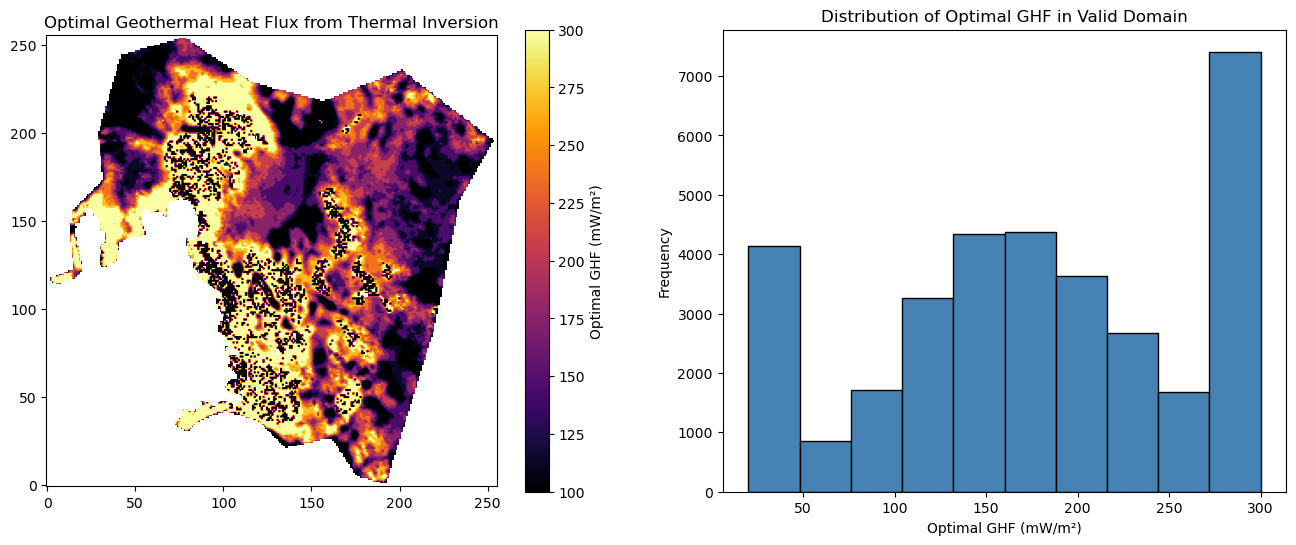

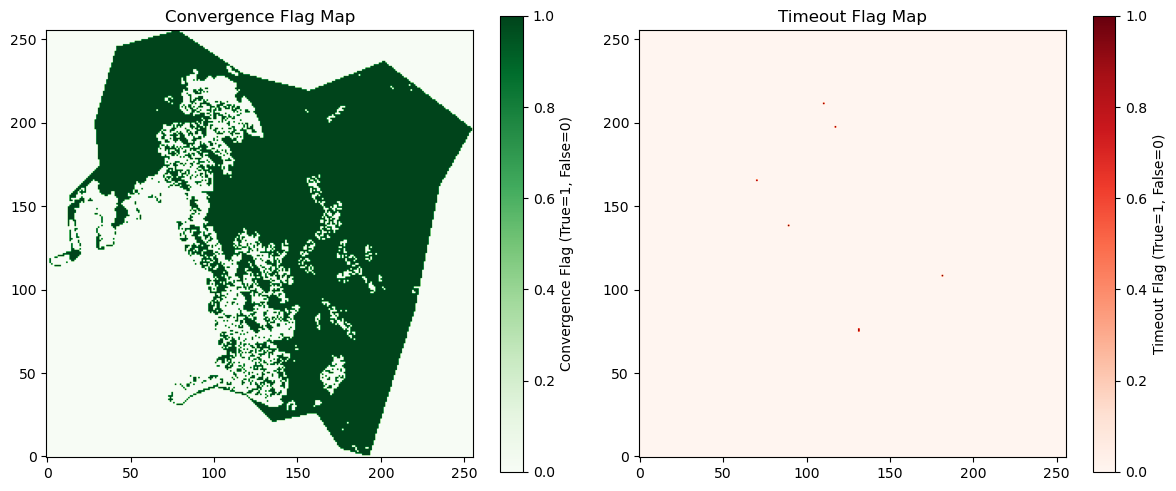

In [10]:
# load the saved data 
ghf_optimal      = np.load("../data/output-time-dependent-thermal/ghf_optimal.npy")
convergence_flag = np.load("../data/output-time-dependent-thermal/convergence_flag.npy")
timeout_flag     = np.load("../data/output-time-dependent-thermal/timeout_flag.npy")
T_profile        = np.load("../data/output-time-dependent-thermal/T_profile.npy")

plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.imshow(ghf_optimal.reshape(256, 256) * 1e3, cmap='inferno', vmin=100, vmax=300)
plt.colorbar(label='Optimal GHF (mW/m²)')
plt.title("Optimal Geothermal Heat Flux from Thermal Inversion")
plt.gca().invert_yaxis()
plt.subplot(1,2,2)
plt.hist(ghf_optimal[valid_pixel.flatten()] * 1e3, color='steelblue', edgecolor='black')
plt.xlabel('Optimal GHF (mW/m²)')
plt.ylabel('Frequency')
plt.title("Distribution of Optimal GHF in Valid Domain")
plt.show()
# plot convergence flag and timeout flag
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.imshow(convergence_flag.reshape(256, 256), cmap='Greens', vmin=0, vmax=1)
plt.colorbar(label='Convergence Flag (True=1, False=0)')
plt.title("Convergence Flag Map")
plt.gca().invert_yaxis()
plt.subplot(1,2,2)
plt.imshow(timeout_flag.reshape(256, 256), cmap='Reds', vmin=0, vmax=1)
plt.colorbar(label='Timeout Flag (True=1, False=0)')
plt.title("Timeout Flag Map")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

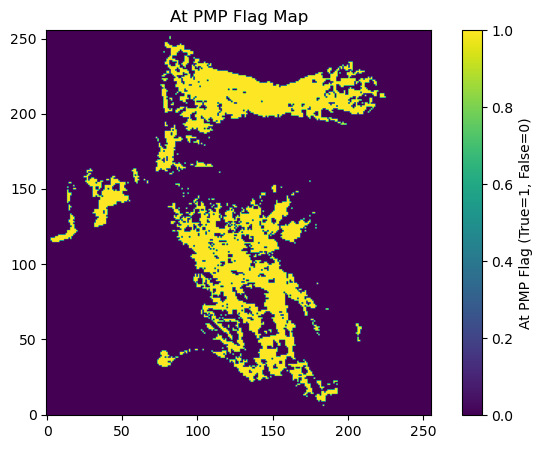

Total number of valid pixels in the domain (revised):  24733


In [11]:
epsilon = 0.1 # degree
at_pmp_flag = np.abs(Tb_target.flatten() - posterior_samples["Tpmp"].flatten()) < epsilon
plt.figure(figsize=(8, 5))
plt.imshow(at_pmp_flag.reshape(256, 256), cmap='viridis')
plt.colorbar(label='At PMP Flag (True=1, False=0)')
plt.title("At PMP Flag Map")
plt.gca().invert_yaxis()
plt.show()

# recompute the total valid pixel, ignoring at pmp pixels
valid_pixel_revised = valid_pixel.flatten() & (~at_pmp_flag)
valid_pixel_revised_idx = np.where(valid_pixel_revised.flatten())[0]

print("Total number of valid pixels in the domain (revised): ", np.sum(valid_pixel_revised))

#### get the surface slope (smoothed)

In [12]:
# x_crop and y_crop are 1D coordinate axes — meshgrid them first
xx_crop, yy_crop = np.meshgrid(x_crop, y_crop)  # both become (2052, 1900)

slope = np.gradient(dem_crop, np.abs(y_crop[1] - y_crop[0]),   # row spacing (y)
                               np.abs(x_crop[1] - x_crop[0]))  # col spacing (x)
slope_magnitude        = np.sqrt(slope[0]**2 + slope[1]**2)
slope_magnitude_smooth = gaussian_filter(slope_magnitude, sigma=4)

# now all three flatten to the same length: 2052*1900
slope_magnitude_interp = griddata(
    (xx_crop.flatten(), yy_crop.flatten()),
    slope_magnitude.flatten(),
    (grid_x, grid_y),
    method='nearest'
)
slope_magnitude_smooth_interp = griddata(
    (xx_crop.flatten(), yy_crop.flatten()),
    slope_magnitude_smooth.flatten(),
    (grid_x, grid_y),
    method='nearest'
)

slope_magnitude_interp[model_bound_data == 0]        = np.nan
slope_magnitude_smooth_interp[model_bound_data == 0] = np.nan


#### visualize all input fields

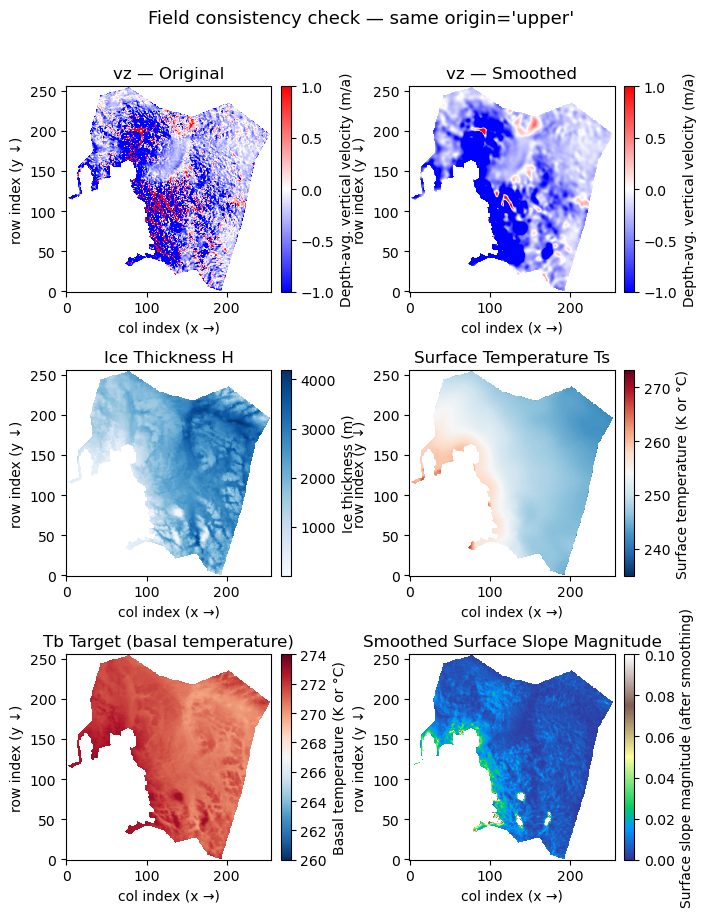

In [13]:
# agreement check again, adding the smoothed surface slope field
Tb_target = posterior_samples["Tpmp"].reshape(256, 256)
Tb_target[model_bound_data == 0] = np.nan

fig, axes = plt.subplots(3, 2, figsize=(7, 9))

# ─── Shared plot kwargs for consistency ───────────────────────────────────────
imshow_kw = dict(origin='upper', aspect='equal')

# ─── Row 0: Vertical velocity (before / after smoothing) ─────────────────────
im0 = axes[0, 0].imshow(vz_grid, cmap='bwr', vmin=-1, vmax=1, **imshow_kw)
axes[0, 0].set_title("vz — Original")
axes[0, 0].set_xlabel("col index (x →)")
axes[0, 0].set_ylabel("row index (y ↓)")
axes[0, 0].invert_yaxis()
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04,
             label='Depth-avg. vertical velocity (m/a)')

im1 = axes[0, 1].imshow(vz_grid_smooth, cmap='bwr', vmin=-1, vmax=1, **imshow_kw)
axes[0, 1].set_title("vz — Smoothed")
axes[0, 1].set_xlabel("col index (x →)")
axes[0, 1].set_ylabel("row index (y ↓)")
axes[0, 1].invert_yaxis()
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04,
             label='Depth-avg. vertical velocity (m/a)')

# ─── Row 1: Ice thickness / Surface temperature ───────────────────────────────
im2 = axes[1, 0].imshow(H_grid, cmap='Blues', **imshow_kw)
axes[1, 0].set_title("Ice Thickness H")
axes[1, 0].set_xlabel("col index (x →)")
axes[1, 0].set_ylabel("row index (y ↓)")
axes[1, 0].invert_yaxis()
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label='Ice thickness (m)')

im3 = axes[1, 1].imshow(Ts_grid, cmap='RdBu_r', **imshow_kw)
axes[1, 1].set_title("Surface Temperature Ts")
axes[1, 1].set_xlabel("col index (x →)")
axes[1, 1].set_ylabel("row index (y ↓)")
axes[1, 1].invert_yaxis()
fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Surface temperature (K or °C)')

# ─── Row 2: Basal temperature target ────────────────────────────
im4 = axes[2, 0].imshow(Tb_target, cmap='RdBu_r',vmin=260,vmax=274, **imshow_kw)
axes[2, 0].set_title("Tb Target (basal temperature)")
axes[2, 0].set_xlabel("col index (x →)")
axes[2, 0].set_ylabel("row index (y ↓)")
axes[2, 0].invert_yaxis()
fig.colorbar(im4, ax=axes[2, 0], fraction=0.046, pad=0.04, label='Basal temperature (K or °C)')

im6 = axes[2, 1].imshow(slope_magnitude_smooth_interp, cmap='terrain', vmin=0, vmax=0.1, **imshow_kw)
axes[2, 1].set_title("Smoothed Surface Slope Magnitude")
axes[2, 1].set_xlabel("col index (x →)")
axes[2, 1].set_ylabel("row index (y ↓)")
axes[2, 1].invert_yaxis()
fig.colorbar(im6, ax=axes[2, 1], fraction=0.046, pad=0.04, label='Surface slope magnitude (after smoothing)')

plt.suptitle("Field consistency check — same origin='upper'", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [14]:
import pickle
import os
import numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed


# ─── Worker initializer ───────────────────────────────────────────────────────
def init_worker(H_grid_, Ts_grid_, vz_grid_smooth_, Tb_target_,
                ghf_optimal_, T_profile_, slope_magnitude_smooth_interp_,
                nz_, year_final_, secinyear_):
    global H_grid, Ts_grid, vz_grid_smooth, Tb_target
    global ghf_optimal, T_profile, slope_magnitude_smooth_interp
    global nz, year_final, secinyear

    H_grid                        = H_grid_
    Ts_grid                       = Ts_grid_
    vz_grid_smooth                = vz_grid_smooth_
    Tb_target                     = Tb_target_
    ghf_optimal                   = ghf_optimal_
    T_profile                     = T_profile_
    slope_magnitude_smooth_interp = slope_magnitude_smooth_interp_
    nz                            = nz_
    year_final                    = year_final_
    secinyear                     = secinyear_


# ─── Per-pixel worker ─────────────────────────────────────────────────────────
def process_pixel_perturb(idx, slope_0, slope_span, delta_slope_fracs, timeout_sec=60):
    from src.ice import strain_heating
    from iceThermalNumericalSolve import ice_thermal_numeric

    h_val         = H_grid.flatten()[idx]
    Ts_val_px     = Ts_grid.flatten()[idx]
    vz_val_px     = vz_grid_smooth.flatten()[idx]
    Tb_target_val = Tb_target.flatten()[idx]
    ghf           = ghf_optimal.flatten()[idx]

    n_delta       = len(slope_span)
    misfit_arr    = np.full(n_delta, np.nan)
    T_md_arr      = np.full((n_delta, nz + 1), np.nan)
    converged_arr = np.zeros(n_delta, dtype=bool)
    status_arr    = ['not_run'] * n_delta

    # ── thin ice guard ────────────────────────────────────────────────────────
    if h_val < 50:
        return idx, misfit_arr, T_md_arr, converged_arr, ['thin_ice'] * n_delta, np.nan

    first_crossing_frac = np.nan   # delta fraction where Tb first crosses PMP

    try:
        T_init = T_profile.flatten()[idx * (nz + 1): (idx + 1) * (nz + 1)]

        for j, slope_new in enumerate(slope_span):

            vz_profile      = np.linspace(0, 2 * vz_val_px, nz + 1) / secinyear
            vz_profile      = vz_profile[::-1]

            with suppress_output():
                md_it = ice_thermal_numeric(T_init, year_final, intSave=200, nz=nz, L=h_val)
                md_it.load_advection(md_it.z, vz_profile)
                md_it.apply_surface_bc(Ts_val_px)
                md_it.apply_base_bc(ghf)

                Q_ori     = strain_heating(slope_0,   h_val, md_it.z)
                Q_perturb = strain_heating(slope_new, h_val, md_it.z)
                Q_diff    = (Q_perturb - Q_ori)[::-1]
                md_it.load_source_term(md_it.z, Q_diff, show_plot=False)
                md_it.solve_steady_state(show_plot=False)

            T_md             = md_it.T_ss[-1]
            misfit           = Tb_target_val - T_md[-1]
            misfit_arr[j]    = misfit
            T_md_arr[j, :]   = T_md
            converged_arr[j] = misfit < 0
            status_arr[j]    = 'converged' if misfit < 0 else 'no_convergence'
            T_init           = T_md   # warm start for next delta

            # ── early abort on first PMP crossing ─────────────────────────────
            if misfit < 0:
                first_crossing_frac = delta_slope_fracs[j]
                for k in range(j + 1, n_delta):
                    status_arr[k] = 'not_needed'
                break

    except Exception as e:
        for j in range(n_delta):
            if status_arr[j] == 'not_run':
                status_arr[j] = 'error'

    return idx, misfit_arr, T_md_arr, converged_arr, status_arr, first_crossing_frac


# ─── Delta slope levels ────────────────────────────────────────────────────────
delta_slope_pct   = np.array([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200])
delta_slope_fracs = delta_slope_pct / 100.0
n_delta           = len(delta_slope_fracs)

# ─── Output arrays ────────────────────────────────────────────────────────────
n_pixels               = len(valid_pixel_revised_idx)
Tb_misfit_slope        = np.full((n_pixels, n_delta), np.nan)
T_profile_slope        = np.full((n_pixels, n_delta, nz + 1), np.nan)
convergence_flag_slope = np.zeros((n_pixels, n_delta), dtype=bool)
timeout_flag_slope     = np.zeros((n_pixels, n_delta), dtype=bool)
first_crossing_fracs   = np.full(n_pixels, np.nan)   # one scalar per pixel

# ─── Load checkpoint ──────────────────────────────────────────────────────────
CHECKPOINT_FILE = "checkpoint_slope_0.pkl"

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "rb") as f:
        ckpt = pickle.load(f)
    Tb_misfit_slope        = ckpt["Tb_misfit_slope"]
    T_profile_slope        = ckpt["T_profile_slope"]
    convergence_flag_slope = ckpt["convergence_flag_slope"]
    timeout_flag_slope     = ckpt["timeout_flag_slope"]
    first_crossing_fracs   = ckpt["first_crossing_fracs"]
    resume_count           = ckpt["last_count"]
    print(f"[RESUME] count={resume_count}")
else:
    resume_count = -1
    print("[FRESH] Starting from scratch")

# ─── Build job list ───────────────────────────────────────────────────────────
pixels_remaining = valid_pixel_revised_idx[resume_count + 1:]

jobs = []
for count, idx in enumerate(pixels_remaining):
    slope_0      = slope_magnitude_smooth_interp.flatten()[idx]
    slope_span   = slope_0 * (1.0 + delta_slope_fracs)
    global_count = count + resume_count + 1
    jobs.append((global_count, idx, slope_0, slope_span))

# ─── Parallel execution ───────────────────────────────────────────────────────
N_WORKERS = 10

with ProcessPoolExecutor(
    max_workers=N_WORKERS,
    initializer=init_worker,
    initargs=(H_grid, Ts_grid, vz_grid_smooth, Tb_target,
              ghf_optimal, T_profile, slope_magnitude_smooth_interp,
              nz, year_final, secinyear)
) as executor:

    futures = {
        executor.submit(
            process_pixel_perturb, idx, slope_0, slope_span, delta_slope_fracs, 60
        ): (global_count, idx)
        for global_count, idx, slope_0, slope_span in jobs
    }

    pbar           = tqdm(as_completed(futures), total=len(futures),
                          desc="Slope perturbation", unit="px")
    completed_counts = []
    n_converged      = 0
    n_thin           = 0
    n_error          = 0

    for future in pbar:
        global_count, idx = futures[future]

        try:
            result_idx, misfit_arr, T_md_arr, converged_arr, status_arr, cross_frac = \
                future.result(timeout=120)
        except Exception as e:
            tqdm.write(f"[ERROR] gc={global_count} idx={idx}: {e}")
            n_error += 1
            continue

        # ── Store ──────────────────────────────────────────────────────────────
        Tb_misfit_slope[global_count, :]        = misfit_arr
        T_profile_slope[global_count, :, :]     = T_md_arr
        convergence_flag_slope[global_count, :] = converged_arr
        first_crossing_fracs[global_count]      = cross_frac

        # ── Tally (no per-pixel prints) ────────────────────────────────────────
        if 'thin_ice' in status_arr:
            n_thin += 1
        elif any(c for c in converged_arr):
            n_converged += 1
        if any(s == 'timeout' for s in status_arr):
            timeout_flag_slope[global_count, :] = [s == 'timeout' for s in status_arr]

        completed_counts.append(global_count)

        # ── Progress bar summary only ──────────────────────────────────────────
        pbar.set_postfix({
            'conv' : n_converged,
            'thin' : n_thin,
            'err'  : n_error,
            'cross': f'{cross_frac*100:.0f}%' if not np.isnan(cross_frac) else '-',
        }, refresh=False)

        # ── Checkpoint every 500 completed ────────────────────────────────────
        if len(completed_counts) % 500 == 0:
            last = max(completed_counts)
            ckpt = {
                'Tb_misfit_slope'       : Tb_misfit_slope,
                'T_profile_slope'       : T_profile_slope,
                'convergence_flag_slope': convergence_flag_slope,
                'timeout_flag_slope'    : timeout_flag_slope,
                'first_crossing_fracs'  : first_crossing_fracs,
                'last_count'            : last,
            }
            with open(f'checkpoint_slope_{last}.pkl', 'wb') as f:
                pickle.dump(ckpt, f)
            tqdm.write(f"[CKPT] {last} | conv={n_converged} thin={n_thin} err={n_error}")

pbar.close()
print(f"Done. converged={n_converged}  thin={n_thin}  errors={n_error}", flush=True)

# ─── Save outputs ─────────────────────────────────────────────────────────────
os.makedirs("../data/output-slope-perturbation/", exist_ok=True)
np.save("../data/output-slope-perturbation/delta_slope_pct.npy",        delta_slope_pct)
np.save("../data/output-slope-perturbation/Tb_misfit_slope.npy",        Tb_misfit_slope)
np.save("../data/output-slope-perturbation/T_profile_slope.npy",        T_profile_slope)
np.save("../data/output-slope-perturbation/convergence_flag_slope.npy", convergence_flag_slope)
np.save("../data/output-slope-perturbation/timeout_flag_slope.npy",     timeout_flag_slope)
np.save("../data/output-slope-perturbation/first_crossing_fracs.npy",   first_crossing_fracs)


[FRESH] Starting from scratch


Slope perturbation:   2%|▏         | 511/24733 [00:37<15:50, 25.48px/s, conv=498, thin=0, err=0, cross=1%]  

[CKPT] 502 | conv=487 thin=0 err=0


Slope perturbation:   4%|▍         | 1000/24733 [01:00<25:43, 15.37px/s, conv=963, thin=0, err=0, cross=10%]

[CKPT] 1005 | conv=963 thin=0 err=0


...

[CKPT] 24003 | conv=20020 thin=11 err=0


Slope perturbation:  99%|█████████▉| 24500/24733 [30:13<00:43,  5.34px/s, conv=20422, thin=11, err=0, cross=1%]  

[CKPT] 24508 | conv=20422 thin=11 err=0


Slope perturbation: 100%|█████████▉| 24732/24733 [35:16<00:00, 11.69px/s, conv=20624, thin=11, err=0, cross=90%] Process ForkProcess-5:
Process ForkProcess-1:
Process ForkProcess-3:
Process ForkProcess-2:
Process ForkProcess-8:
Process ForkProcess-10:
Process ForkProcess-4:
Process ForkProcess-7:
Process ForkProcess-6:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/donglaiyang/anaconda3/envs/SciML/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/home/donglaiyang/anaconda3/envs/SciML/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/home/donglaiyang/anaconda3/envs/SciML/lib/python3.9/multiprocessing/process.py", line 315, in _bo

KeyboardInterrupt: 

In [44]:
# post processing crossing frac for visualization
# replace the non-converging pixels with max frac values so that they appear in the plot (rather than nan)
first_crossing_fracs_plot = np.where(
    np.isnan(first_crossing_fracs),
    1.0,  # max frac (100% perturbation) for non-converging pixels
    first_crossing_fracs)

first_crossing_fracs_full = np.nan * np.ones_like(Tb_target.flatten())
first_crossing_fracs_full[valid_pixel_revised_idx] = first_crossing_fracs

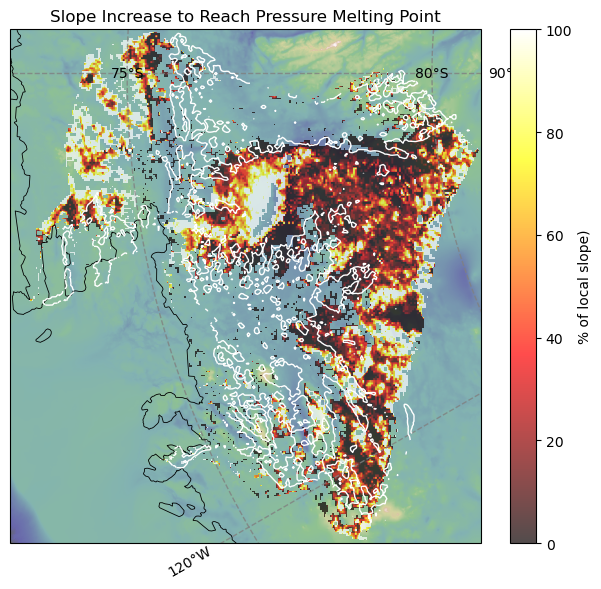

In [54]:

proj     = ccrs.SouthPolarStereo()
data_crs = ccrs.epsg(3031)

fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={'projection': proj}   # ← SouthPolarStereo for axes, NOT data_crs
)

ax.set_extent([x_min, x_max, y_min, y_max], crs=data_crs)
ax.add_feature(cfeature.COASTLINE, zorder=3, edgecolor='black', linewidth=0.6)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=1, color='grey', alpha=0.8, linestyle='--', zorder=5
)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}
gl.xlocator   = plt.FixedLocator(range(-180, 181, 30))
gl.ylocator   = plt.FixedLocator(range(-90, -59, 5))
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# ── Hillshade ─────────────────────────────────────────────────────────────────
ax.imshow(
    bed_crop,
    origin='upper',                   # ← keep upper, same as working example
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='gist_earth', alpha=0.6, zorder=0
)

# ── First crossing fraction map ───────────────────────────────────────────────
im0 = ax.imshow(
    first_crossing_fracs_full.reshape(256, 256) * 100,   # convert to %
    origin='lower',                   # ← same as working example
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot', vmin=0, vmax=100,
    alpha=0.7, zorder=1
)

# -- contour (0.5) of deg_to_mean_val
contour_levels = [1]
cs = ax.contour(
    grid_x, grid_y, deg_to_mean_val.reshape(256, 256),
    levels=contour_levels,
    colors='white', linewidths=1.0, zorder=4
)
# ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')

ax.set_title("Slope Increase to Reach Pressure Melting Point", fontsize=12)
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04,
             label='% of local slope)')

plt.tight_layout()
plt.savefig("../figs/threshold_slope_frac.png", dpi=300)
plt.show()

